tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


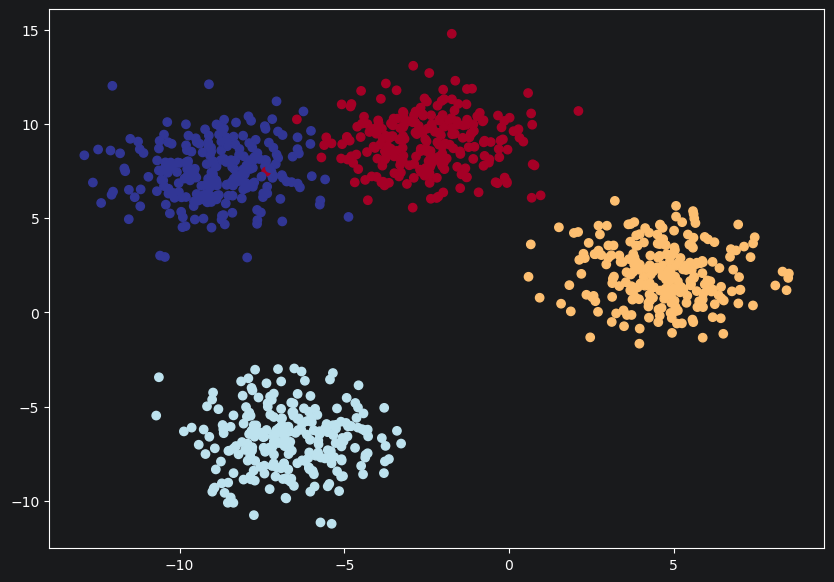

In [1]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [2]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from torch import nn

# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [4]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1) # exercise: try changing the learning rate here and seeing what happens to the model's performance

In [5]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]

tensor([[ 0.1792,  0.8853, -1.0000,  0.3516],
        [ 0.7025,  0.8057, -0.3427,  1.5066],
        [-1.5785, -1.1344,  1.7839,  0.5278],
        [-0.9871, -0.5751,  1.1096,  0.6816],
        [ 0.4194,  0.5659, -0.0809,  1.3833]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [6]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [7]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.3055,  0.9521, -1.0290,  0.4780],
        [ 0.2644,  0.1864,  0.6041,  1.7559],
        [-1.3865, -0.8695,  1.3830,  0.4299],
        [-0.0996,  0.6112, -0.6593,  0.2976],
        [ 0.8380,  1.0451, -0.7400,  1.3446]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.2293, 0.4378, 0.0604, 0.2725],
        [0.1286, 0.1190, 0.1807, 0.5717],
        [0.0404, 0.0677, 0.6438, 0.2482],
        [0.1963, 0.3996, 0.1121, 0.2920],
        [0.2441, 0.3003, 0.0504, 0.4052]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [8]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[:5], dim=1)

tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SumBackward1>)

In [9]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.2293, 0.4378, 0.0604, 0.2725], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(1, device='cuda:0')


In [10]:
from helper_functions import accuracy_fn, plot_decision_boundary

# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.86601, Acc: 74.50% | Test Loss: 0.52311, Test Acc: 95.50%
Epoch: 10 | Loss: 0.13836, Acc: 98.75% | Test Loss: 0.12653, Test Acc: 99.50%
Epoch: 20 | Loss: 0.07996, Acc: 99.00% | Test Loss: 0.07213, Test Acc: 99.50%
Epoch: 30 | Loss: 0.05980, Acc: 99.12% | Test Loss: 0.05207, Test Acc: 99.50%
Epoch: 40 | Loss: 0.04992, Acc: 99.12% | Test Loss: 0.04195, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04416, Acc: 99.12% | Test Loss: 0.03592, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04042, Acc: 99.12% | Test Loss: 0.03194, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03781, Acc: 99.12% | Test Loss: 0.02914, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03591, Acc: 99.12% | Test Loss: 0.02705, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03446, Acc: 99.12% | Test Loss: 0.02545, Test Acc: 99.50%


In [11]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[  6.4061,  11.5866, -12.0592,  -6.9078],
        [  4.3773,  -9.7482,   2.6517,  10.3626],
        [-11.7972, -15.0084,  18.3511,   9.7225],
        [  2.2572,   7.9505,  -6.6229,  -5.1529],
        [ 11.0791,   6.1847, -12.3293,  -0.9143],
        [  4.8406, -12.3439,   3.8946,  12.6857],
        [-11.9491, -12.1130,  16.6837,   7.2452],
        [  9.0230,   1.9028,  -8.1068,   2.0367],
        [-12.5178, -20.0759,  22.0291,  13.7501],
        [  9.5847,   3.4198,  -9.4743,   0.9392]], device='cuda:0')

In [12]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.5%


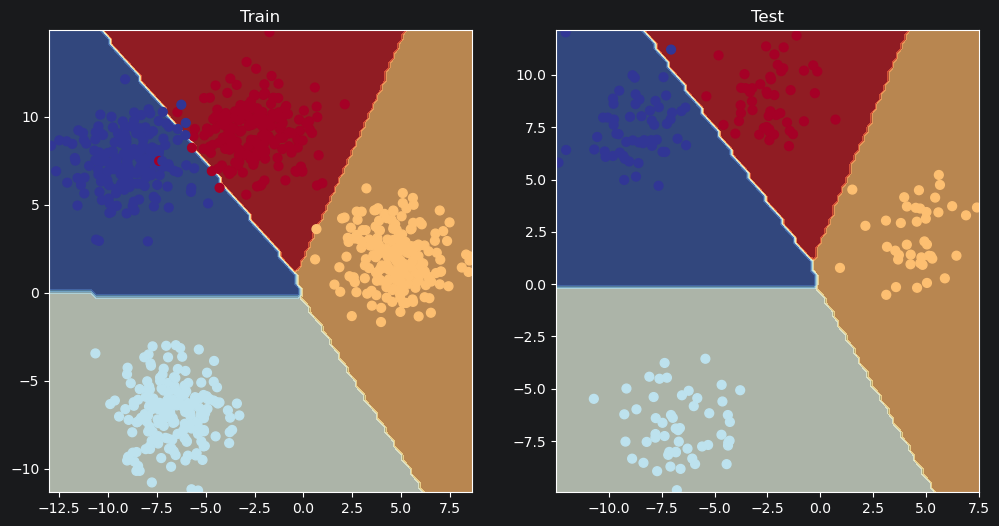

In [13]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [14]:
try:
    from torchmetrics import Accuracy
except:
    #!pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

tensor(0.9950, device='cuda:0')